# Task 4: Augmentation Impact / Robustness Analysis

This notebook supports Task 4 of the TechTrack case analysis. The task measures the effects of Gaussian blur, vertical flip, and brightness adjustments on the performance of the best-performing model selected in Task 1.

The design question is:

**How robust is Model 2 to image transformations that affect blur, orientation, and lighting?**

The analysis uses the 5,000-image rare-aware density-stratified sample from Task 2 and the NMS IoU threshold of 0.50 selected in Task 3.

## Methodology

The experiment holds the system configuration fixed and varies only the image condition.

Fixed setup:

- Model: `Model 2`
- Dataset: Task 2 selected 5,000-image sample
- Score threshold: `0.5`
- NMS IoU threshold: `0.5`
- Evaluation IoU threshold: `0.5`
- Metric: mAP@0.5 using 11-point interpolation
- Evaluation pipeline: implemented `metrics.py`

Image conditions tested:

1. Original images
2. Gaussian blur, kernel size 9
3. Vertical flip
4. Brightness increase, alpha 1.15 and beta 35
5. Brightness decrease, alpha 0.85 and beta -35

For Gaussian blur and brightness adjustments, the ground-truth boxes remain unchanged because object positions do not move. For vertical flip, the ground-truth boxes are also vertically flipped so that evaluation remains valid.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        expected = candidate / "analysis" / "outputs" / "task4_aug_summary_by_condition_selected_sample.csv"
        if expected.exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing Task 4 output CSVs.")

ROOT = find_repo_root(Path.cwd())
OUT = ROOT / "analysis" / "outputs"
FIG = ROOT / "analysis" / "figures"

summary = pd.read_csv(OUT / "task4_aug_summary_by_condition_selected_sample.csv")
per_class = pd.read_csv(OUT / "task4_aug_per_class_ap_by_condition_selected_sample.csv")

condition_order = [
    "original",
    "gaussian_blur_k9",
    "vertical_flip",
    "brightness_increase",
    "brightness_decrease",
]

order_map = {tag: i for i, tag in enumerate(condition_order)}
summary["condition_order"] = summary["augmentation_condition"].map(order_map)
summary = summary.sort_values("condition_order").reset_index(drop=True)

summary.shape, per_class.shape

((5, 16), (100, 11))

## Table 1: Augmentation Impact Summary

This table summarizes the effect of each image transformation on Model 2 performance.

In [2]:
summary_display = summary.rename(columns={
    "augmentation_display": "Image Condition",
    "mAP@0.5_11_point": "mAP@0.5",
    "mAP_change_vs_original": "mAP Change vs Original",
    "mAP_percent_change_vs_original": "Percent Change vs Original",
    "total_ground_truth": "Ground Truth Objects",
    "total_predictions_after_nms": "Predictions After NMS",
    "prediction_change_vs_original": "Prediction Change vs Original",
})

summary_display["mAP@0.5"] = summary_display["mAP@0.5"].round(6)
summary_display["mAP Change vs Original"] = summary_display["mAP Change vs Original"].round(6)
summary_display["Percent Change vs Original"] = summary_display["Percent Change vs Original"].round(2)

summary_display[[
    "Image Condition",
    "mAP@0.5",
    "mAP Change vs Original",
    "Percent Change vs Original",
    "Ground Truth Objects",
    "Predictions After NMS",
    "Prediction Change vs Original",
]]

,Image Condition,mAP@0.5,mAP Change vs Original,Percent Change vs Original,Ground Truth Objects,Predictions After NMS,Prediction Change vs Original
0,Original,0.550528,0.000000,0.00,19196,11157,0
1,Gaussian blur,0.411794,-0.138734,-25.20,19196,6230,-4927
2,Vertical flip,0.312042,-0.238486,-43.32,19196,5355,-5802
3,Brightness increase,0.535916,-0.014612,-2.65,19196,10622,-535
4,Brightness decrease,0.520518,-0.030009,-5.45,19196,10024,-1133


**Interpretation.** Vertical flip causes the largest performance degradation, reducing mAP@0.5 from 0.5505 to 0.3120. Gaussian blur also causes a substantial drop, reducing mAP@0.5 to 0.4118. Brightness changes have a smaller effect: brightness increase reduces mAP by about 2.65%, while brightness decrease reduces mAP by about 5.45%. This suggests that Model 2 is much more sensitive to geometric inversion and blur than to moderate lighting changes.

## Figure 1: Visual Examples of Augmentations

This figure demonstrates the image transformations used in the robustness analysis.

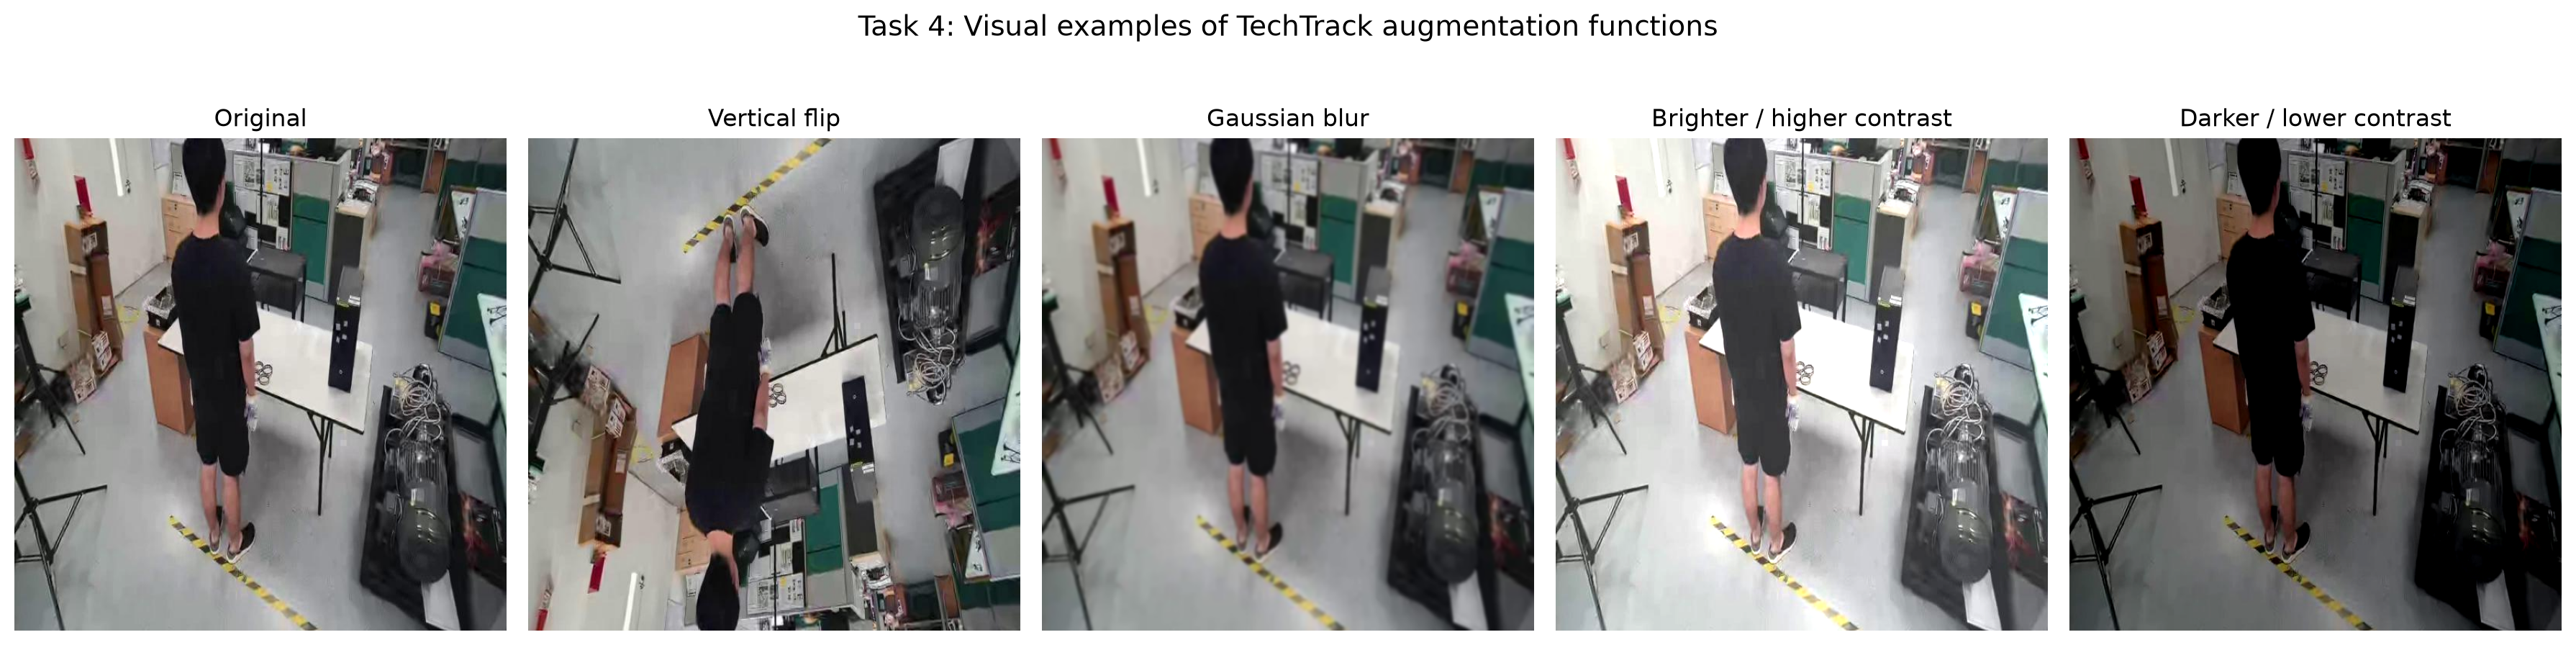

In [3]:
display(Image(filename=str(FIG / "task4_augmentation_examples.png")))

**Interpretation.** The visual examples confirm that the implemented augmentation functions produce the intended transformations. The vertical flip changes the spatial orientation of the scene, Gaussian blur reduces edge and texture sharpness, and brightness adjustments change illumination without moving object locations.

## Figure 2: Model 2 mAP@0.5 by Image Condition

This figure compares absolute mAP@0.5 across the original and augmented image conditions.

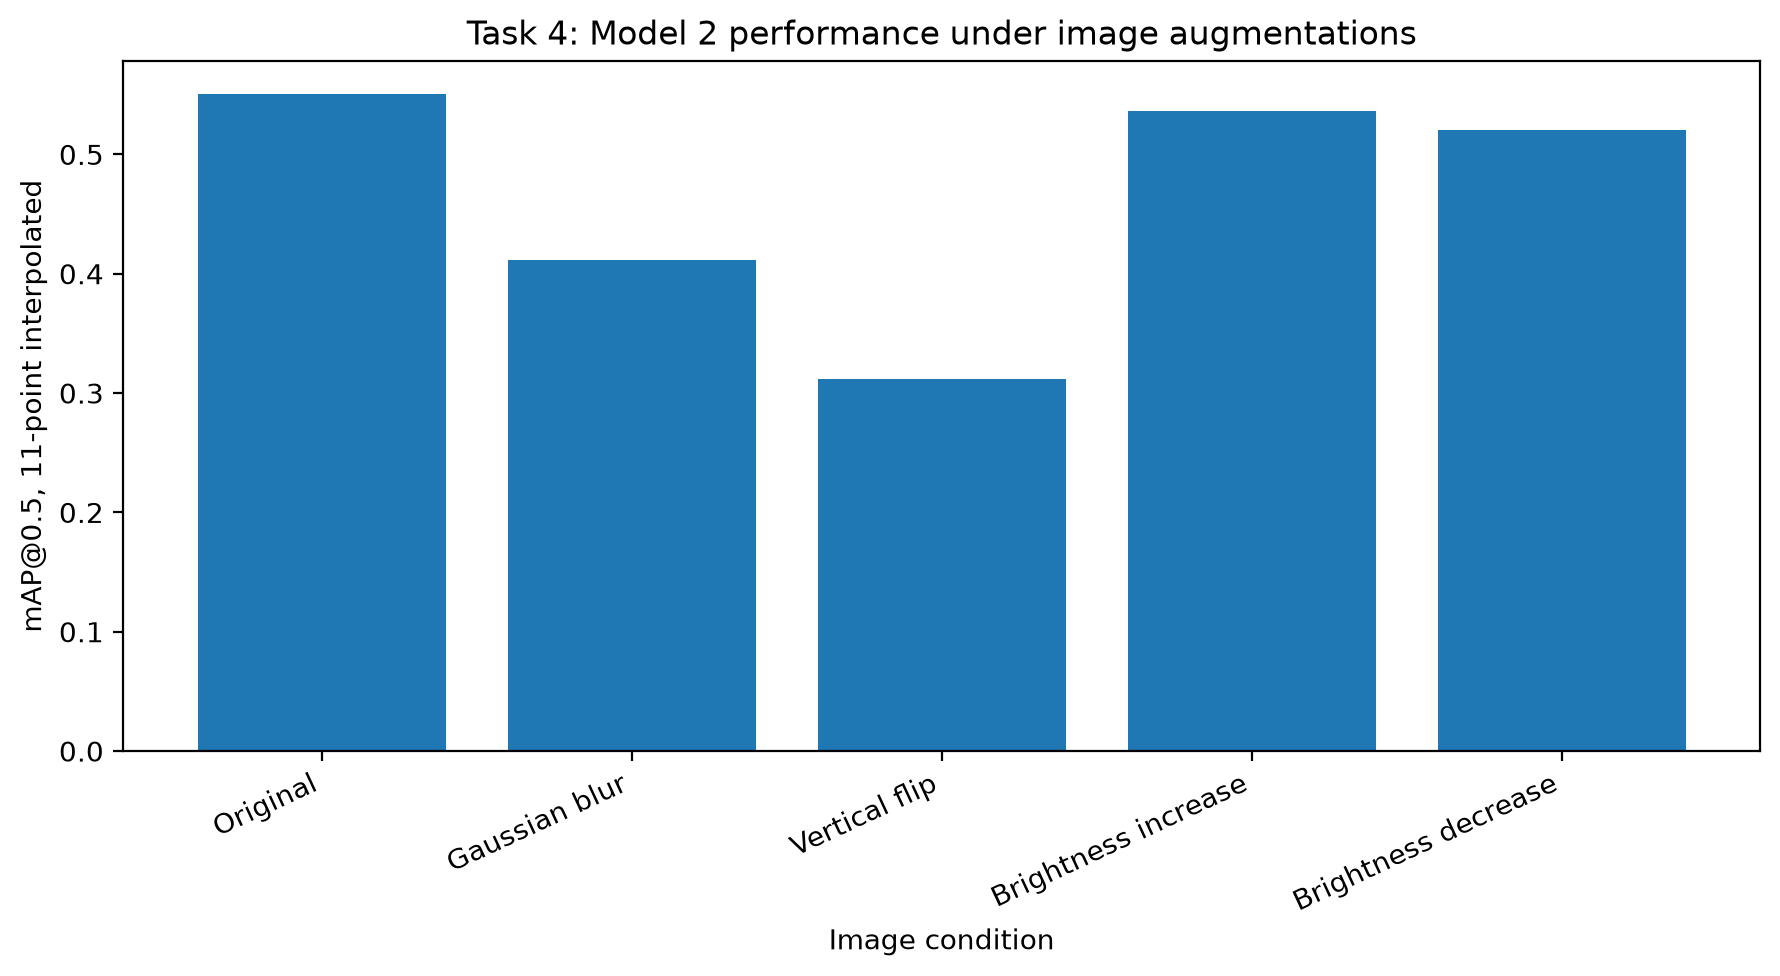

In [4]:
display(Image(filename=str(FIG / "task4_aug_map_by_condition_selected_sample.png")))

**Interpretation.** The absolute mAP chart shows that the original images perform best. Brightness changes remain relatively close to the original condition, while Gaussian blur and vertical flip produce much lower mAP. This supports the conclusion that the model is not equally robust to all transformations.

## Figure 3: mAP@0.5 Drop vs Original

This figure shows performance degradation as a positive drop from the original-image baseline.

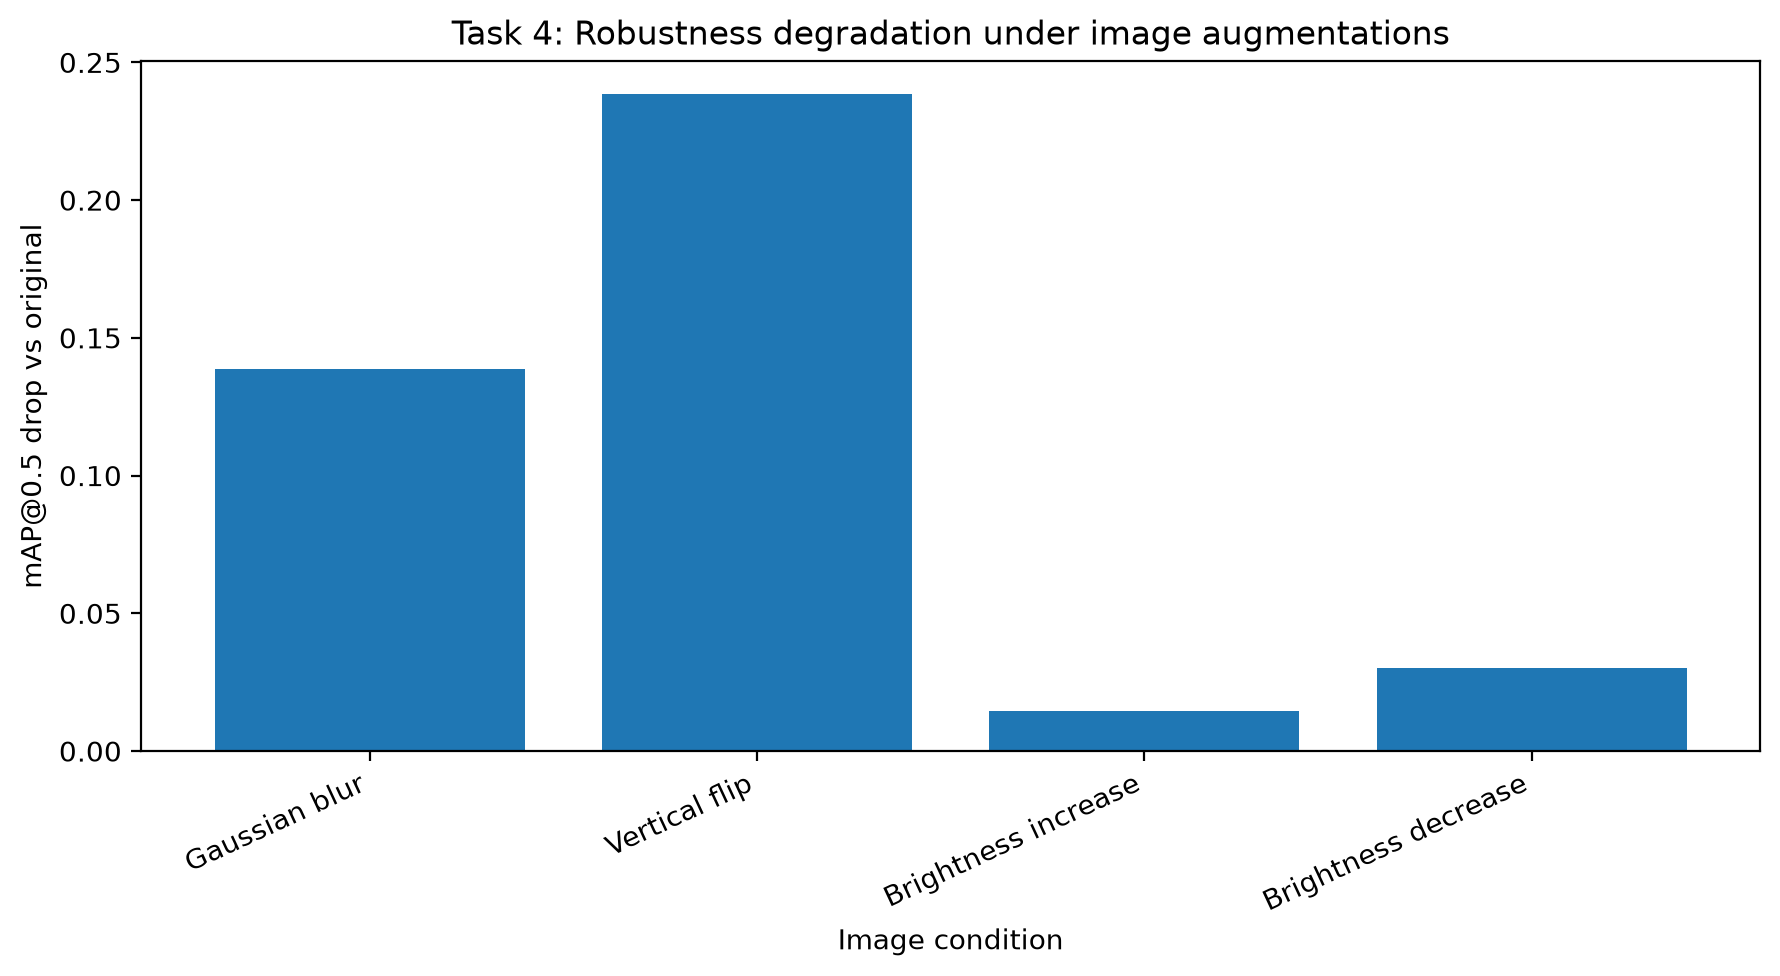

In [5]:
display(Image(filename=str(FIG / "task4_aug_map_drop_vs_original_selected_sample.png")))

**Interpretation.** Expressing the result as mAP drop makes the robustness impact clearer. Vertical flip has the largest drop, followed by Gaussian blur. Brightness decrease is more damaging than brightness increase, but both brightness conditions are much less damaging than blur or vertical flip.

## Figure 4: Post-NMS Prediction Count by Image Condition

This figure shows how many predictions remain after fixed NMS at threshold 0.50.

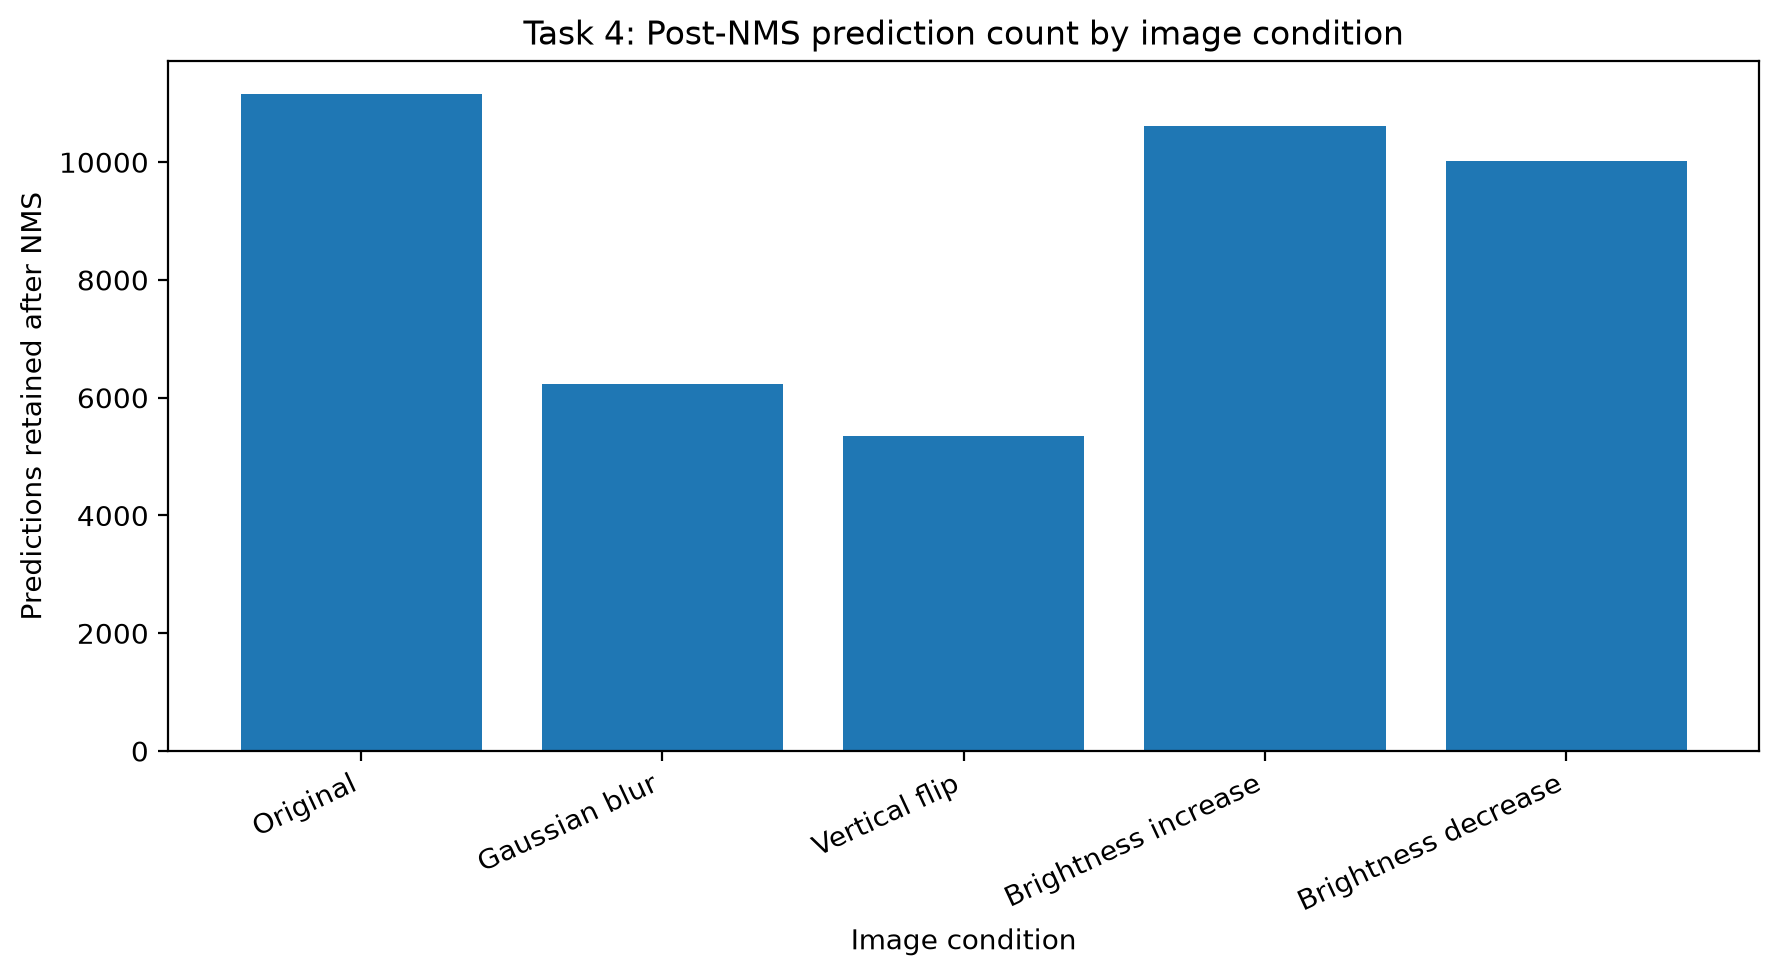

In [6]:
display(Image(filename=str(FIG / "task4_aug_prediction_count_by_condition_selected_sample.png")))

**Interpretation.** The number of retained detections drops sharply under Gaussian blur and vertical flip. This indicates that the model is not only making poorer matches under these transformations; it is also producing fewer confident detections that survive post-processing. Brightness changes reduce prediction count only moderately, which is consistent with their smaller mAP drop.

## Table 2: Largest Per-Class AP Drops

This table identifies the class and augmentation combinations with the largest AP losses compared with original images.

In [7]:
non_original = per_class[per_class["augmentation_condition"] != "original"].copy()
non_original["ap_drop_vs_original"] = -non_original["ap_change_vs_original"]

largest_drops = (
    non_original
    .sort_values("ap_drop_vs_original", ascending=False)
    .head(15)
    .copy()
)

largest_drops_display = largest_drops.rename(columns={
    "augmentation_display": "Image Condition",
    "class_name": "Class",
    "ground_truth_count": "Ground Truth Count",
    "prediction_count": "Prediction Count",
    "ap_11_point": "AP@0.5",
    "original_ap_11_point": "Original AP@0.5",
    "ap_drop_vs_original": "AP Drop vs Original",
})

for col in ["AP@0.5", "Original AP@0.5", "AP Drop vs Original"]:
    largest_drops_display[col] = largest_drops_display[col].round(6)

largest_drops_display[[
    "Image Condition",
    "Class",
    "Ground Truth Count",
    "Prediction Count",
    "Original AP@0.5",
    "AP@0.5",
    "AP Drop vs Original",
]]

,Image Condition,Class,Ground Truth Count,Prediction Count,Original AP@0.5,AP@0.5,AP Drop vs Original
44,Vertical flip,forklift,583,33,0.715011,0.081569,0.633442
55,Vertical flip,traffic cone,240,23,0.728098,0.139992,0.588107
58,Vertical flip,van,394,117,0.789553,0.264829,0.524725
46,Vertical flip,gloves,134,37,0.640392,0.119771,0.520620
41,Vertical flip,car,737,103,0.632194,0.197890,0.434304
53,Vertical flip,safety vest,659,135,0.530797,0.174751,0.356046
47,Vertical flip,helmet,1159,46,0.499414,0.149634,0.349780
37,Gaussian blur,truck,415,203,0.760691,0.415218,0.345474
54,Vertical flip,smoke,795,28,0.398008,0.085878,0.312130
50,Vertical flip,person,3272,580,0.586777,0.311147,0.275630


**Interpretation.** The largest class-level AP drops are concentrated under vertical flip. Forklift, traffic cone, van, gloves, car, safety vest, helmet, smoke, and person all lose substantial AP under vertical flipping. Gaussian blur also causes large drops for truck, helmet, and van. This matters because several of these are operationally or safety-relevant classes in a warehouse environment.

## Figure 5: Largest Per-Class AP Drops

This figure visualizes the largest class-specific performance losses under augmentation.

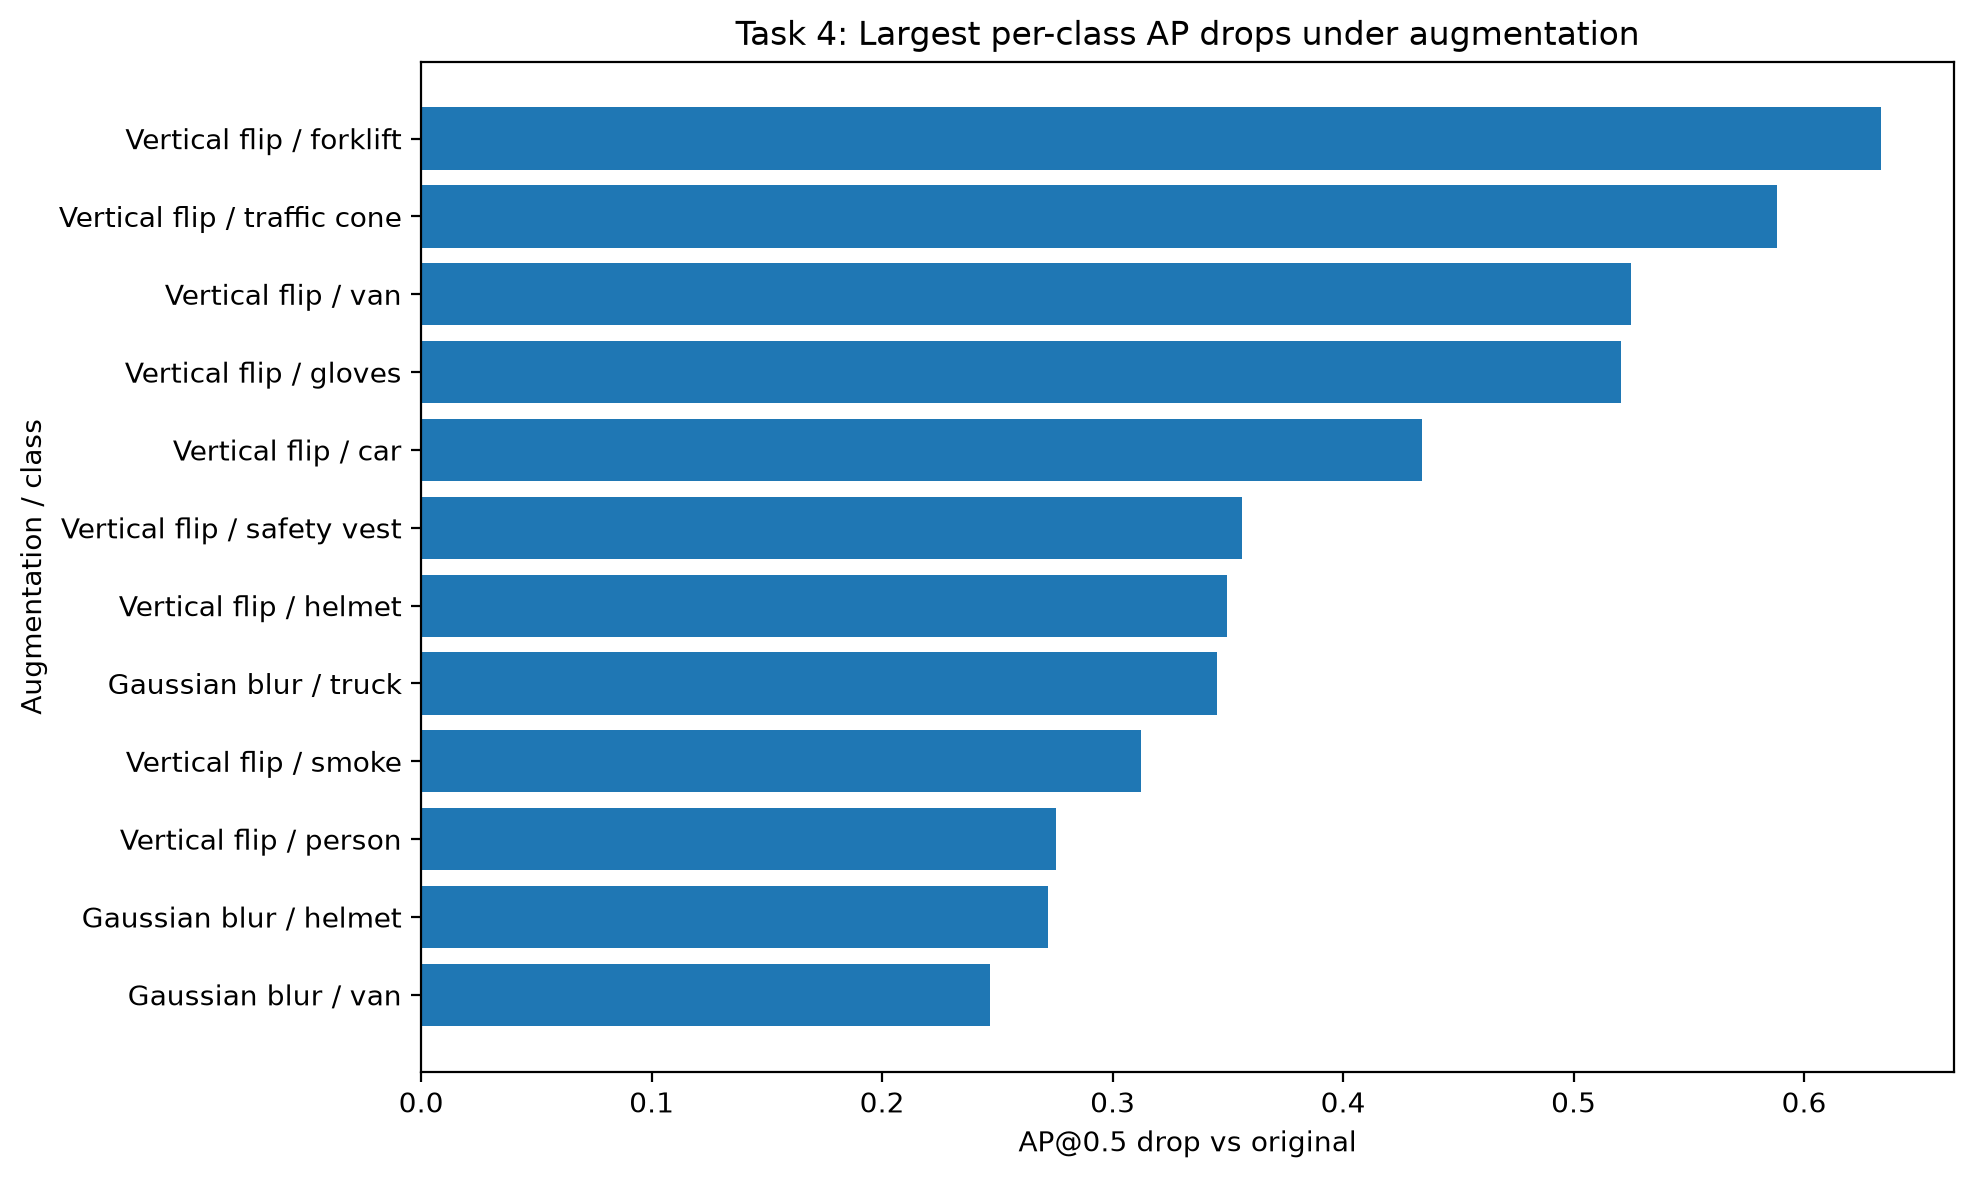

In [8]:
display(Image(filename=str(FIG / "task4_aug_largest_per_class_ap_drops_selected_sample.png")))

**Interpretation.** The figure reinforces that vertical flip is the most damaging transformation. This is expected for a fixed-camera warehouse setting because vertical inversion changes the scene geometry in a way that is unlikely to match the model's training distribution. Gaussian blur is also damaging, especially for classes that depend on edges, texture, shape detail, or small visual features.

## Task 4 Conclusion

Task 4 shows that Model 2 is not equally robust to all visual transformations. The largest degradation occurs under vertical flip, where mAP@0.5 falls from 0.5505 to 0.3120. Gaussian blur also causes a large drop, reducing mAP@0.5 to 0.4118. Brightness changes are less damaging, with mAP@0.5 remaining above 0.5200 for both brightened and darkened images.

The design implication is that augmentation should be selected based on operational realism. Brightness augmentation is likely useful because lighting variation is realistic in warehouse environments and the model is relatively tolerant to it. Gaussian blur should be included in robustness planning because blur can occur from motion, focus issues, or camera quality, and the current model is vulnerable to it. Vertical flip should be treated carefully because it produces the largest degradation and may not represent a realistic warehouse camera condition unless inverted cameras are expected.

At the class level, the largest failures affect operational and safety-relevant classes such as forklift, traffic cone, gloves, safety vest, helmet, smoke, truck, and person. These results suggest that future rectification should focus not only on aggregate robustness, but also on class-specific weaknesses under realistic visual degradation.

## Appendix A: Task 4 Experiment Script

This appendix records the script used to generate the Task 4 results.

### `analysis/task4_augmentation_impact.py`

```python
from pathlib import Path
import sys
import argparse
import json
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(__file__).resolve().parents[1]
sys.path.insert(0, str(ROOT))

from techtrack.modules.inference.model import Detector
from techtrack.modules.inference.nms import NMS
from techtrack.modules.rectification.augmentation import Augmenter
from techtrack.modules.utils.metrics import (
    match_detections,
    calculate_precision_recall_curve,
    calculate_map_x_point_interpolated,
)

OUT = ROOT / "analysis" / "outputs"
FIG = ROOT / "analysis" / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

PREFIX = "task4_aug"

SAMPLE_INDEX = OUT / "task2_selected_sample_index.csv"
CLASS_FILE = ROOT / "techtrack" / "storage" / "yolo_model_2" / "logistics.names"

MODEL2 = {
    "weights": ROOT / "techtrack/storage/yolo_model_2/yolov4-tiny-logistics_size_416_2.weights",
    "cfg": ROOT / "techtrack/storage/yolo_model_2/yolov4-tiny-logistics_size_416_2.cfg",
    "names": ROOT / "techtrack/storage/yolo_model_2/logistics.names",
}

MODEL_NAME = "model2"
DATASET_NAME = "rare_aware_density_stratified_5000"

SCORE_THRESHOLD = 0.5
NMS_THRESHOLD = 0.5
MAP_IOU_THRESHOLD = 0.5
EVAL_TYPE = "combined"

CONDITIONS = [
    {
        "tag": "original",
        "display": "Original",
        "type": "none",
    },
    {
        "tag": "gaussian_blur_k9",
        "display": "Gaussian blur",
        "type": "gaussian_blur",
        "kernel_size": 9,
        "sigma": 0,
    },
    {
        "tag": "vertical_flip",
        "display": "Vertical flip",
        "type": "vertical_flip",
    },
    {
        "tag": "brightness_increase",
        "display": "Brightness increase",
        "type": "brightness",
        "alpha": 1.15,
        "beta": 35,
    },
    {
        "tag": "brightness_decrease",
        "display": "Brightness decrease",
        "type": "brightness",
        "alpha": 0.85,
        "beta": -35,
    },
]

RAW_COLUMNS = [
    "model",
    "dataset",
    "augmentation_condition",
    "augmentation_display",
    "image_file",
    "image_path",
    "bbox_x",
    "bbox_y",
    "bbox_w",
    "bbox_h",
    "class_id",
    "class_name",
    "object_score",
    "predicted_class_score",
    "combined_confidence",
    "class_scores_json",
]

PRED_COLUMNS = RAW_COLUMNS + ["nms_threshold"]

GT_COLUMNS = [
    "dataset",
    "augmentation_condition",
    "augmentation_display",
    "image_file",
    "image_path",
    "class_id",
    "class_name",
    "bbox_x",
    "bbox_y",
    "bbox_w",
    "bbox_h",
]


def load_classes():
    return [line.strip() for line in CLASS_FILE.read_text().splitlines() if line.strip()]


def apply_condition_to_image(image_bgr, condition):
    condition_type = condition["type"]

    if condition_type == "none":
        return image_bgr

    if condition_type == "gaussian_blur":
        return Augmenter.gaussian_blur(
            image=image_bgr,
            kernel_size=condition.get("kernel_size", 9),
            sigma=condition.get("sigma", 0),
        )

    if condition_type == "vertical_flip":
        return Augmenter.vertical_flip(image=image_bgr)

    if condition_type == "brightness":
        return Augmenter.change_brightness(
            image=image_bgr,
            alpha=condition.get("alpha", 1.0),
            beta=condition.get("beta", 0),
        )

    raise ValueError(f"Unsupported condition type: {condition_type}")


def yolo_label_to_xywh_for_condition(label_path: Path, image_w: int, image_h: int, classes, condition):
    rows = []
    text = label_path.read_text().strip()

    if not text:
        return rows

    for line in text.splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue

        class_id = int(float(parts[0]))
        if class_id < 0 or class_id >= len(classes):
            continue

        x_center = float(parts[1]) * image_w
        y_center = float(parts[2]) * image_h
        box_w = float(parts[3]) * image_w
        box_h = float(parts[4]) * image_h

        x = x_center - box_w / 2
        y = y_center - box_h / 2

        if condition["type"] == "vertical_flip":
            # Convert top-left y for vertically flipped image.
            y = image_h - y - box_h

        # Clip only to protect against tiny floating point boundary issues.
        x = float(np.clip(x, 0, image_w))
        y = float(np.clip(y, 0, image_h))
        box_w = float(np.clip(box_w, 0, image_w))
        box_h = float(np.clip(box_h, 0, image_h))

        rows.append({
            "class_id": class_id,
            "class_name": classes[class_id],
            "bbox_x": x,
            "bbox_y": y,
            "bbox_w": box_w,
            "bbox_h": box_h,
        })

    return rows


def build_ground_truth(idx, classes, condition, suffix, force=False):
    tag = condition["tag"]
    gt_path = OUT / f"{PREFIX}_ground_truth_{tag}{suffix}.csv"

    if gt_path.exists() and not force:
        print(f"[SKIP] Ground truth already exists: {gt_path}")
        return pd.read_csv(gt_path)

    print("=" * 100)
    print(f"Building Task 4 ground-truth table for condition: {condition['display']}")
    print("=" * 100)

    rows = []

    for row_num, (_, row) in enumerate(idx.iterrows(), start=1):
        image_path = ROOT / row["image_path"]
        label_path = ROOT / row["label_path"]

        frame = cv2.imread(str(image_path))
        if frame is None:
            print(f"[WARN] Could not read image for GT conversion: {image_path}")
            continue

        image_h, image_w = frame.shape[:2]

        for gt in yolo_label_to_xywh_for_condition(label_path, image_w, image_h, classes, condition):
            rows.append({
                "dataset": DATASET_NAME,
                "augmentation_condition": tag,
                "augmentation_display": condition["display"],
                "image_file": row["image_file"],
                "image_path": row["image_path"],
                "class_id": gt["class_id"],
                "class_name": gt["class_name"],
                "bbox_x": gt["bbox_x"],
                "bbox_y": gt["bbox_y"],
                "bbox_w": gt["bbox_w"],
                "bbox_h": gt["bbox_h"],
            })

        if row_num % 1000 == 0:
            print(f"[GT {tag}] processed {row_num}/{len(idx)} images")

    gt_df = pd.DataFrame(rows, columns=GT_COLUMNS)
    gt_df.to_csv(gt_path, index=False)

    print(f"[WRITE] {gt_path} rows={len(gt_df)}")
    return gt_df


def run_raw_inference(idx, classes, condition, suffix, force=False):
    tag = condition["tag"]
    raw_path = OUT / f"{PREFIX}_{MODEL_NAME}_raw_predictions_{tag}{suffix}.csv"

    if raw_path.exists() and not force:
        print(f"[SKIP] Raw predictions already exist: {raw_path}")
        return pd.read_csv(raw_path)

    print("=" * 100)
    print(f"Running Model 2 inference for condition: {condition['display']}")
    print("=" * 100)

    detector = Detector(
        str(MODEL2["weights"]),
        str(MODEL2["cfg"]),
        str(MODEL2["names"]),
        score_threshold=SCORE_THRESHOLD,
    )

    rows = []
    start = time.time()

    for row_num, (_, row) in enumerate(idx.iterrows(), start=1):
        image_path = ROOT / row["image_path"]
        frame = cv2.imread(str(image_path))

        if frame is None:
            print(f"[WARN] Could not read image: {image_path}")
            continue

        frame = apply_condition_to_image(frame, condition)

        outputs = detector.predict(frame)
        bboxes, class_ids, scores, class_scores = detector.post_process(outputs)

        for det_idx, bbox in enumerate(bboxes):
            class_id = int(class_ids[det_idx])
            object_score = float(scores[det_idx])

            score_vector = np.asarray(class_scores[det_idx], dtype=float).ravel()
            score_vector = [float(v) for v in score_vector]

            if 0 <= class_id < len(score_vector):
                predicted_class_score = float(score_vector[class_id])
            else:
                predicted_class_score = 0.0

            combined_confidence = object_score * predicted_class_score

            rows.append({
                "model": MODEL_NAME,
                "dataset": DATASET_NAME,
                "augmentation_condition": tag,
                "augmentation_display": condition["display"],
                "image_file": row["image_file"],
                "image_path": row["image_path"],
                "bbox_x": float(bbox[0]),
                "bbox_y": float(bbox[1]),
                "bbox_w": float(bbox[2]),
                "bbox_h": float(bbox[3]),
                "class_id": class_id,
                "class_name": classes[class_id] if 0 <= class_id < len(classes) else "unknown",
                "object_score": object_score,
                "predicted_class_score": predicted_class_score,
                "combined_confidence": combined_confidence,
                "class_scores_json": json.dumps(score_vector),
            })

        if row_num % 250 == 0:
            elapsed = time.time() - start
            print(
                f"[RAW {tag}] processed {row_num}/{len(idx)} images | "
                f"raw detections={len(rows)} | elapsed={elapsed:.1f}s"
            )

    raw_df = pd.DataFrame(rows, columns=RAW_COLUMNS)
    raw_df.to_csv(raw_path, index=False)

    elapsed = time.time() - start
    print(f"[WRITE] {raw_path} rows={len(raw_df)}")
    print(f"[DONE] raw inference elapsed seconds: {elapsed:.2f}")

    return raw_df


def apply_fixed_nms(raw_df, idx, classes, condition, suffix, force=False):
    tag = condition["tag"]
    pred_path = OUT / f"{PREFIX}_{MODEL_NAME}_predictions_{tag}_nms_0_5{suffix}.csv"

    if pred_path.exists() and not force:
        print(f"[SKIP] NMS predictions already exist: {pred_path}")
        return pd.read_csv(pred_path)

    print("=" * 100)
    print(f"Applying fixed NMS threshold = {NMS_THRESHOLD} for condition: {condition['display']}")
    print("=" * 100)

    nms = NMS(
        score_threshold=SCORE_THRESHOLD,
        nms_iou_threshold=NMS_THRESHOLD,
    )

    raw_groups = {k: v for k, v in raw_df.groupby("image_file")} if len(raw_df) else {}
    rows = []

    for row_num, (_, row) in enumerate(idx.iterrows(), start=1):
        image_file = row["image_file"]
        group = raw_groups.get(image_file)

        if group is None or len(group) == 0:
            continue

        bboxes = group[["bbox_x", "bbox_y", "bbox_w", "bbox_h"]].astype(float).values.tolist()
        class_ids = group["class_id"].astype(int).tolist()
        scores = group["object_score"].astype(float).tolist()
        class_scores = [
            json.loads(value)
            for value in group["class_scores_json"].tolist()
        ]

        filtered_boxes, filtered_classes, filtered_scores, filtered_class_scores = nms.filter(
            bboxes,
            class_ids,
            scores,
            class_scores,
        )

        for det_idx, bbox in enumerate(filtered_boxes):
            class_id = int(filtered_classes[det_idx])
            object_score = float(filtered_scores[det_idx])

            score_vector = np.asarray(filtered_class_scores[det_idx], dtype=float).ravel()
            score_vector = [float(v) for v in score_vector]

            if 0 <= class_id < len(score_vector):
                predicted_class_score = float(score_vector[class_id])
            else:
                predicted_class_score = 0.0

            combined_confidence = object_score * predicted_class_score

            rows.append({
                "model": MODEL_NAME,
                "dataset": DATASET_NAME,
                "augmentation_condition": tag,
                "augmentation_display": condition["display"],
                "image_file": row["image_file"],
                "image_path": row["image_path"],
                "bbox_x": float(bbox[0]),
                "bbox_y": float(bbox[1]),
                "bbox_w": float(bbox[2]),
                "bbox_h": float(bbox[3]),
                "class_id": class_id,
                "class_name": classes[class_id] if 0 <= class_id < len(classes) else "unknown",
                "object_score": object_score,
                "predicted_class_score": predicted_class_score,
                "combined_confidence": combined_confidence,
                "class_scores_json": json.dumps(score_vector),
                "nms_threshold": NMS_THRESHOLD,
            })

        if row_num % 1000 == 0:
            print(f"[NMS {tag}] processed {row_num}/{len(idx)} images")

    pred_df = pd.DataFrame(rows, columns=PRED_COLUMNS)
    pred_df.to_csv(pred_path, index=False)

    print(f"[WRITE] {pred_path} rows={len(pred_df)}")
    return pred_df


def build_metric_lists(idx, pred_df, gt_df):
    pred_groups = {k: v for k, v in pred_df.groupby("image_file")} if len(pred_df) else {}
    gt_groups = {k: v for k, v in gt_df.groupby("image_file")} if len(gt_df) else {}

    boxes = []
    pred_classes = []
    scores = []
    cls_scores = []

    gt_boxes = []
    gt_classes = []

    for _, row in idx.iterrows():
        image_file = row["image_file"]

        pred_group = pred_groups.get(image_file)
        if pred_group is None:
            boxes.append([])
            pred_classes.append([])
            scores.append([])
            cls_scores.append([])
        else:
            boxes.append(pred_group[["bbox_x", "bbox_y", "bbox_w", "bbox_h"]].values.tolist())
            pred_classes.append(pred_group["class_id"].astype(int).tolist())
            scores.append(pred_group["object_score"].astype(float).tolist())
            cls_scores.append([
                json.loads(value)
                for value in pred_group["class_scores_json"].tolist()
            ])

        gt_group = gt_groups.get(image_file)
        if gt_group is None:
            gt_boxes.append([])
            gt_classes.append([])
        else:
            gt_boxes.append(gt_group[["bbox_x", "bbox_y", "bbox_w", "bbox_h"]].values.tolist())
            gt_classes.append(gt_group["class_id"].astype(int).tolist())

    return boxes, pred_classes, scores, cls_scores, gt_boxes, gt_classes


def evaluate_with_metrics_py(idx, pred_df, gt_df, classes, condition):
    boxes, pred_classes, scores, cls_scores, gt_boxes, gt_classes = build_metric_lists(
        idx,
        pred_df,
        gt_df,
    )

    y_true, pred_scores = match_detections(
        boxes=boxes,
        classes=pred_classes,
        scores=scores,
        cls_scores=cls_scores,
        gt_boxes=gt_boxes,
        gt_classes=gt_classes,
        map_iou_threshold=MAP_IOU_THRESHOLD,
        eval_type=EVAL_TYPE,
    )

    precision, recall, thresholds = calculate_precision_recall_curve(
        y_true,
        pred_scores,
        num_classes=len(classes),
    )

    precision_recall_points = {
        class_id: list(zip(recall[class_id], precision[class_id]))
        for class_id in range(len(classes))
    }

    map_score = calculate_map_x_point_interpolated(
        precision_recall_points,
        num_classes=len(classes),
        num_interpolated_points=11,
    )

    per_class_rows = []

    for class_id, class_name in enumerate(classes):
        per_class_ap = calculate_map_x_point_interpolated(
            {0: precision_recall_points[class_id]},
            num_classes=1,
            num_interpolated_points=11,
        )

        gt_count = int((gt_df["class_id"] == class_id).sum())
        prediction_count = int((pred_df["class_id"] == class_id).sum()) if len(pred_df) else 0

        per_class_rows.append({
            "model": MODEL_NAME,
            "dataset": DATASET_NAME,
            "augmentation_condition": condition["tag"],
            "augmentation_display": condition["display"],
            "class_id": class_id,
            "class_name": class_name,
            "ground_truth_count": gt_count,
            "prediction_count": prediction_count,
            "ap_11_point": per_class_ap,
        })

    summary = {
        "model": MODEL_NAME,
        "dataset": DATASET_NAME,
        "augmentation_condition": condition["tag"],
        "augmentation_display": condition["display"],
        "mAP@0.5_11_point": map_score,
        "total_ground_truth": int(len(gt_df)),
        "total_predictions_after_nms": int(len(pred_df)),
        "evaluation_rows": int(len(y_true)),
        "score_threshold": SCORE_THRESHOLD,
        "nms_threshold": NMS_THRESHOLD,
        "map_iou_threshold": MAP_IOU_THRESHOLD,
        "eval_type": EVAL_TYPE,
    }

    return summary, pd.DataFrame(per_class_rows)


def add_change_from_original(summary_df, per_class_df):
    original_map = float(
        summary_df.loc[
            summary_df["augmentation_condition"] == "original",
            "mAP@0.5_11_point"
        ].iloc[0]
    )

    original_predictions = int(
        summary_df.loc[
            summary_df["augmentation_condition"] == "original",
            "total_predictions_after_nms"
        ].iloc[0]
    )

    summary_df = summary_df.copy()
    summary_df["mAP_change_vs_original"] = summary_df["mAP@0.5_11_point"] - original_map
    summary_df["mAP_percent_change_vs_original"] = (
        summary_df["mAP_change_vs_original"] / original_map * 100
        if original_map != 0 else 0.0
    )
    summary_df["prediction_change_vs_original"] = (
        summary_df["total_predictions_after_nms"] - original_predictions
    )

    original_ap = (
        per_class_df[per_class_df["augmentation_condition"] == "original"]
        [["class_id", "ap_11_point"]]
        .rename(columns={"ap_11_point": "original_ap_11_point"})
    )

    per_class_df = per_class_df.merge(original_ap, on="class_id", how="left")
    per_class_df["ap_change_vs_original"] = (
        per_class_df["ap_11_point"] - per_class_df["original_ap_11_point"]
    )

    return summary_df, per_class_df


def build_figures(summary_df, per_class_df, suffix):
    ordered = summary_df.copy()
    condition_order = [c["tag"] for c in CONDITIONS]
    display_order = [c["display"] for c in CONDITIONS]
    order_map = {tag: i for i, tag in enumerate(condition_order)}
    ordered["condition_order"] = ordered["augmentation_condition"].map(order_map)
    ordered = ordered.sort_values("condition_order")

    plt.figure(figsize=(9, 5))
    plt.bar(ordered["augmentation_display"], ordered["mAP@0.5_11_point"])
    plt.xlabel("Image condition")
    plt.ylabel("mAP@0.5, 11-point interpolated")
    plt.title("Task 4: Augmentation impact on Model 2 mAP@0.5")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    fig1 = FIG / f"{PREFIX}_map_by_condition{suffix}.png"
    plt.savefig(fig1, dpi=200, bbox_inches="tight")
    plt.close()

    drop_df = ordered[ordered["augmentation_condition"] != "original"].copy()
    drop_df["mAP_drop_vs_original"] = -drop_df["mAP_change_vs_original"]

    plt.figure(figsize=(9, 5))
    plt.bar(drop_df["augmentation_display"], drop_df["mAP_drop_vs_original"])
    plt.xlabel("Image condition")
    plt.ylabel("mAP@0.5 drop vs original")
    plt.title("Task 4: Robustness degradation under image augmentations")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    fig2 = FIG / f"{PREFIX}_map_drop_vs_original{suffix}.png"
    plt.savefig(fig2, dpi=200, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(9, 5))
    plt.bar(ordered["augmentation_display"], ordered["total_predictions_after_nms"])
    plt.xlabel("Image condition")
    plt.ylabel("Predictions retained after NMS")
    plt.title("Task 4: Post-NMS prediction count by augmentation condition")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    fig3 = FIG / f"{PREFIX}_prediction_count_by_condition{suffix}.png"
    plt.savefig(fig3, dpi=200, bbox_inches="tight")
    plt.close()

    non_original = per_class_df[per_class_df["augmentation_condition"] != "original"].copy()
    non_original["ap_drop_vs_original"] = -non_original["ap_change_vs_original"]

    top_drops = (
        non_original
        .sort_values("ap_drop_vs_original", ascending=False)
        .head(12)
        .copy()
    )
    top_drops["label"] = top_drops["augmentation_display"] + " / " + top_drops["class_name"]
    plot_df = top_drops.sort_values("ap_drop_vs_original", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["label"], plot_df["ap_drop_vs_original"])
    plt.xlabel("AP@0.5 drop vs original")
    plt.ylabel("Augmentation / class")
    plt.title("Task 4: Largest per-class AP drops under augmentation")
    plt.tight_layout()
    fig4 = FIG / f"{PREFIX}_largest_per_class_ap_drops{suffix}.png"
    plt.savefig(fig4, dpi=200, bbox_inches="tight")
    plt.close()

    print("[WRITE]", fig1)
    print("[WRITE]", fig2)
    print("[WRITE]", fig3)
    print("[WRITE]", fig4)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--max-images", type=int, default=None)
    parser.add_argument("--force", action="store_true")
    args = parser.parse_args()

    if not SAMPLE_INDEX.exists():
        raise FileNotFoundError(
            f"Missing selected sample index: {SAMPLE_INDEX}. "
            "Run Task 2 sampling first."
        )

    classes = load_classes()
    idx = pd.read_csv(SAMPLE_INDEX)

    if args.max_images is not None:
        idx = idx.head(args.max_images).copy()
        suffix = f"_first_{args.max_images}"
        print(f"[INFO] Running Task 4 on first {args.max_images} selected sample images.")
    else:
        suffix = "_selected_sample"
        print("[INFO] Running Task 4 on full selected 5,000-image sample.")

    print(f"[INFO] Images selected: {len(idx)}")
    print(f"[INFO] Classes: {len(classes)}")
    print(f"[INFO] Model held constant: {MODEL_NAME}")
    print(f"[INFO] Dataset held constant: {DATASET_NAME}")
    print(f"[INFO] Score threshold held constant: {SCORE_THRESHOLD}")
    print(f"[INFO] NMS threshold held constant: {NMS_THRESHOLD}")
    print(f"[INFO] Evaluation IoU threshold held constant: {MAP_IOU_THRESHOLD}")
    print(f"[INFO] Augmentation conditions tested: {[c['tag'] for c in CONDITIONS]}")
    print(f"[INFO] Output prefix: {PREFIX}_")

    summary_rows = []
    per_class_all = []

    for condition in CONDITIONS:
        gt_df = build_ground_truth(
            idx,
            classes,
            condition,
            suffix=suffix,
            force=args.force,
        )

        raw_df = run_raw_inference(
            idx,
            classes,
            condition,
            suffix=suffix,
            force=args.force,
        )

        pred_df = apply_fixed_nms(
            raw_df,
            idx,
            classes,
            condition,
            suffix=suffix,
            force=args.force,
        )

        summary, per_class_df = evaluate_with_metrics_py(
            idx,
            pred_df,
            gt_df,
            classes,
            condition,
        )

        summary_rows.append(summary)
        per_class_all.append(per_class_df)

    summary_df = pd.DataFrame(summary_rows)
    per_class_df = pd.concat(per_class_all, axis=0, ignore_index=True)

    summary_df, per_class_df = add_change_from_original(summary_df, per_class_df)

    summary_path = OUT / f"{PREFIX}_summary_by_condition{suffix}.csv"
    per_class_path = OUT / f"{PREFIX}_per_class_ap_by_condition{suffix}.csv"

    summary_df.to_csv(summary_path, index=False)
    per_class_df.to_csv(per_class_path, index=False)

    print()
    print("TASK 4 AUGMENTATION SUMMARY")
    print(summary_df.to_string(index=False))

    print()
    print("TASK 4 LARGEST PER-CLASS AP DROPS")
    print(
        per_class_df[per_class_df["augmentation_condition"] != "original"]
        .sort_values("ap_change_vs_original")
        .head(15)
        .to_string(index=False)
    )

    print()
    print("[WRITE]", summary_path)
    print("[WRITE]", per_class_path)

    build_figures(summary_df, per_class_df, suffix=suffix)


if __name__ == "__main__":
    main()

```

### `techtrack/modules/rectification/augmentation.py`

```python
import cv2
import numpy as np
import random
from typing import Optional, Tuple, Union


class Augmenter:
    """
    Dataset augmentation utilities for TechTrack.

    Supported transformations:
    - horizontal_flip
    - vertical_flip
    - gaussian_blur
    - resize
    - change_brightness
    - transform

    The methods support image-only use and optional bounding-box transformation.

    Bounding-box formats supported:
    - "yolo": rows shaped [class_id, x_center, y_center, width, height]
              where coordinates are normalized to [0, 1]
    - "xyxy": rows shaped [class_id, x1, y1, x2, y2]
              where coordinates are pixel coordinates

    By default, methods return only the transformed image.
    If boxes are supplied through `boxes=...`, methods return `(image, boxes)`.
    """

    @staticmethod
    def _validate_image(image):
        if image is None:
            raise ValueError("Expected keyword argument 'image', but got None.")
        if not isinstance(image, np.ndarray):
            raise TypeError("image must be a NumPy array.")
        if image.ndim not in (2, 3):
            raise ValueError("image must be a 2D grayscale or 3D color array.")
        return image

    @staticmethod
    def _copy_boxes(boxes):
        if boxes is None:
            return None
        arr = np.asarray(boxes, dtype=np.float32).copy()
        if arr.ndim != 2 or arr.shape[1] < 5:
            raise ValueError("boxes must have shape [N, >=5].")
        return arr

    @staticmethod
    def _return(image, boxes):
        if boxes is None:
            return image
        return image, boxes

    @staticmethod
    def horizontal_flip(**kwargs):
        """
        Horizontally flip the image.

        Parameters:
            image: NumPy image array.
            boxes: Optional bounding boxes.
            box_format: "yolo" or "xyxy".

        Returns:
            image if boxes are not supplied;
            otherwise (image, boxes).
        """
        image = Augmenter._validate_image(kwargs.get("image"))
        boxes = Augmenter._copy_boxes(kwargs.get("boxes"))
        box_format = kwargs.get("box_format", "yolo")

        flipped = cv2.flip(image, 1)

        if boxes is not None:
            h, w = image.shape[:2]

            if box_format == "yolo":
                # [class_id, x_center, y_center, width, height], normalized
                boxes[:, 1] = 1.0 - boxes[:, 1]

            elif box_format == "xyxy":
                # [class_id, x1, y1, x2, y2], pixel coordinates
                x1 = boxes[:, 1].copy()
                x2 = boxes[:, 3].copy()
                boxes[:, 1] = w - x2
                boxes[:, 3] = w - x1

            else:
                raise ValueError("box_format must be either 'yolo' or 'xyxy'.")

        return Augmenter._return(flipped, boxes)

    @staticmethod
    def vertical_flip(**kwargs):
        """
        Vertically flip the image.

        Parameters:
            image: NumPy image array.
            boxes: Optional bounding boxes.
            box_format: "yolo" or "xyxy".

        Returns:
            image if boxes are not supplied;
            otherwise (image, boxes).
        """
        image = Augmenter._validate_image(kwargs.get("image"))
        boxes = Augmenter._copy_boxes(kwargs.get("boxes"))
        box_format = kwargs.get("box_format", "yolo")

        flipped = cv2.flip(image, 0)

        if boxes is not None:
            h, w = image.shape[:2]

            if box_format == "yolo":
                # [class_id, x_center, y_center, width, height], normalized
                boxes[:, 2] = 1.0 - boxes[:, 2]

            elif box_format == "xyxy":
                # [class_id, x1, y1, x2, y2], pixel coordinates
                y1 = boxes[:, 2].copy()
                y2 = boxes[:, 4].copy()
                boxes[:, 2] = h - y2
                boxes[:, 4] = h - y1

            else:
                raise ValueError("box_format must be either 'yolo' or 'xyxy'.")

        return Augmenter._return(flipped, boxes)

    @staticmethod
    def gaussian_blur(**kwargs):
        """
        Apply Gaussian blur to the image.

        Parameters:
            image: NumPy image array.
            boxes: Optional bounding boxes. Boxes are unchanged.
            kernel_size: Odd integer kernel size. Default: 5.
            sigma: Gaussian sigma. Default: 0.

        Returns:
            image if boxes are not supplied;
            otherwise (image, boxes).
        """
        image = Augmenter._validate_image(kwargs.get("image"))
        boxes = Augmenter._copy_boxes(kwargs.get("boxes"))

        kernel_size = int(kwargs.get("kernel_size", 5))
        sigma = float(kwargs.get("sigma", 0))

        if kernel_size <= 0:
            raise ValueError("kernel_size must be positive.")
        if kernel_size % 2 == 0:
            kernel_size += 1

        blurred = cv2.GaussianBlur(image, (kernel_size, kernel_size), sigma)

        return Augmenter._return(blurred, boxes)

    @staticmethod
    def resize(**kwargs):
        """
        Resize the image.

        Parameters:
            image: NumPy image array.
            boxes: Optional bounding boxes.
            box_format: "yolo" or "xyxy".
            width: Target width.
            height: Target height.
            interpolation: OpenCV interpolation flag.

        Returns:
            image if boxes are not supplied;
            otherwise (image, boxes).
        """
        image = Augmenter._validate_image(kwargs.get("image"))
        boxes = Augmenter._copy_boxes(kwargs.get("boxes"))
        box_format = kwargs.get("box_format", "yolo")

        original_h, original_w = image.shape[:2]
        target_w = kwargs.get("width")
        target_h = kwargs.get("height")

        if target_w is None or target_h is None:
            scale = kwargs.get("scale")
            if scale is None:
                raise ValueError("resize requires either width/height or scale.")
            scale = float(scale)
            if scale <= 0:
                raise ValueError("scale must be positive.")
            target_w = int(round(original_w * scale))
            target_h = int(round(original_h * scale))

        target_w = int(target_w)
        target_h = int(target_h)

        if target_w <= 0 or target_h <= 0:
            raise ValueError("width and height must be positive.")

        interpolation = kwargs.get("interpolation", cv2.INTER_LINEAR)
        resized = cv2.resize(image, (target_w, target_h), interpolation=interpolation)

        if boxes is not None:
            if box_format == "yolo":
                # Normalized YOLO boxes do not change under resizing.
                pass

            elif box_format == "xyxy":
                scale_x = target_w / original_w
                scale_y = target_h / original_h
                boxes[:, [1, 3]] *= scale_x
                boxes[:, [2, 4]] *= scale_y

            else:
                raise ValueError("box_format must be either 'yolo' or 'xyxy'.")

        return Augmenter._return(resized, boxes)

    @staticmethod
    def change_brightness(**kwargs):
        """
        Adjust brightness and contrast.

        Parameters:
            image: NumPy image array.
            boxes: Optional bounding boxes. Boxes are unchanged.
            alpha: Contrast multiplier. Default: 1.0.
            beta: Brightness offset. Default: 30.

        Formula:
            output = image * alpha + beta

        Returns:
            image if boxes are not supplied;
            otherwise (image, boxes).
        """
        image = Augmenter._validate_image(kwargs.get("image"))
        boxes = Augmenter._copy_boxes(kwargs.get("boxes"))

        alpha = float(kwargs.get("alpha", 1.0))
        beta = float(kwargs.get("beta", 30))

        adjusted = image.astype(np.float32) * alpha + beta
        adjusted = np.clip(adjusted, 0, 255).astype(np.uint8)

        return Augmenter._return(adjusted, boxes)

    @staticmethod
    def transform(**kwargs):
        """
        Apply a random sequence of augmentations.

        Parameters:
            image: NumPy image array.
            boxes: Optional bounding boxes.
            box_format: "yolo" or "xyxy".
            max_transforms: Maximum number of transforms to apply. Default: 3.
            seed: Optional random seed.

        Returns:
            image if boxes are not supplied;
            otherwise (image, boxes).
        """
        image = Augmenter._validate_image(kwargs.get("image"))
        boxes = Augmenter._copy_boxes(kwargs.get("boxes"))

        seed = kwargs.get("seed")
        rng = random.Random(seed)

        box_format = kwargs.get("box_format", "yolo")
        max_transforms = int(kwargs.get("max_transforms", 3))
        max_transforms = max(1, max_transforms)

        available = [
            "vertical_flip",
            "gaussian_blur",
            "change_brightness",
        ]

        # Resize is excluded from the default random chain because resizing can
        # complicate later evaluation unless the entire pipeline expects the new size.
        if kwargs.get("include_resize", False):
            available.append("resize")

        rng.shuffle(available)
        n_transforms = rng.randint(1, min(max_transforms, len(available)))
        selected = available[:n_transforms]

        current_image = image.copy()
        current_boxes = boxes.copy() if boxes is not None else None

        for name in selected:
            method = getattr(Augmenter, name)

            method_kwargs = dict(kwargs)
            method_kwargs["image"] = current_image
            method_kwargs["boxes"] = current_boxes
            method_kwargs["box_format"] = box_format

            result = method(**method_kwargs)

            if current_boxes is None:
                current_image = result
            else:
                current_image, current_boxes = result

        return Augmenter._return(current_image, current_boxes)

```